In [18]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [19]:
df = sns.load_dataset('titanic')

df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# handle missing values 
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [20]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)


In [21]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape

(712, 8)

In [22]:
# Create and Train the Model
tree_model = DecisionTreeClassifier(random_state=42) # Koi max_depth nahi di (Fully grown)
tree_model.fit(X_train, y_train)

# Predictions
y_pred_train = tree_model.predict(X_train)
y_pred_test = tree_model.predict(X_test)

# Check Accuracy
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

Training Accuracy: 0.9789
Testing Accuracy: 0.7821


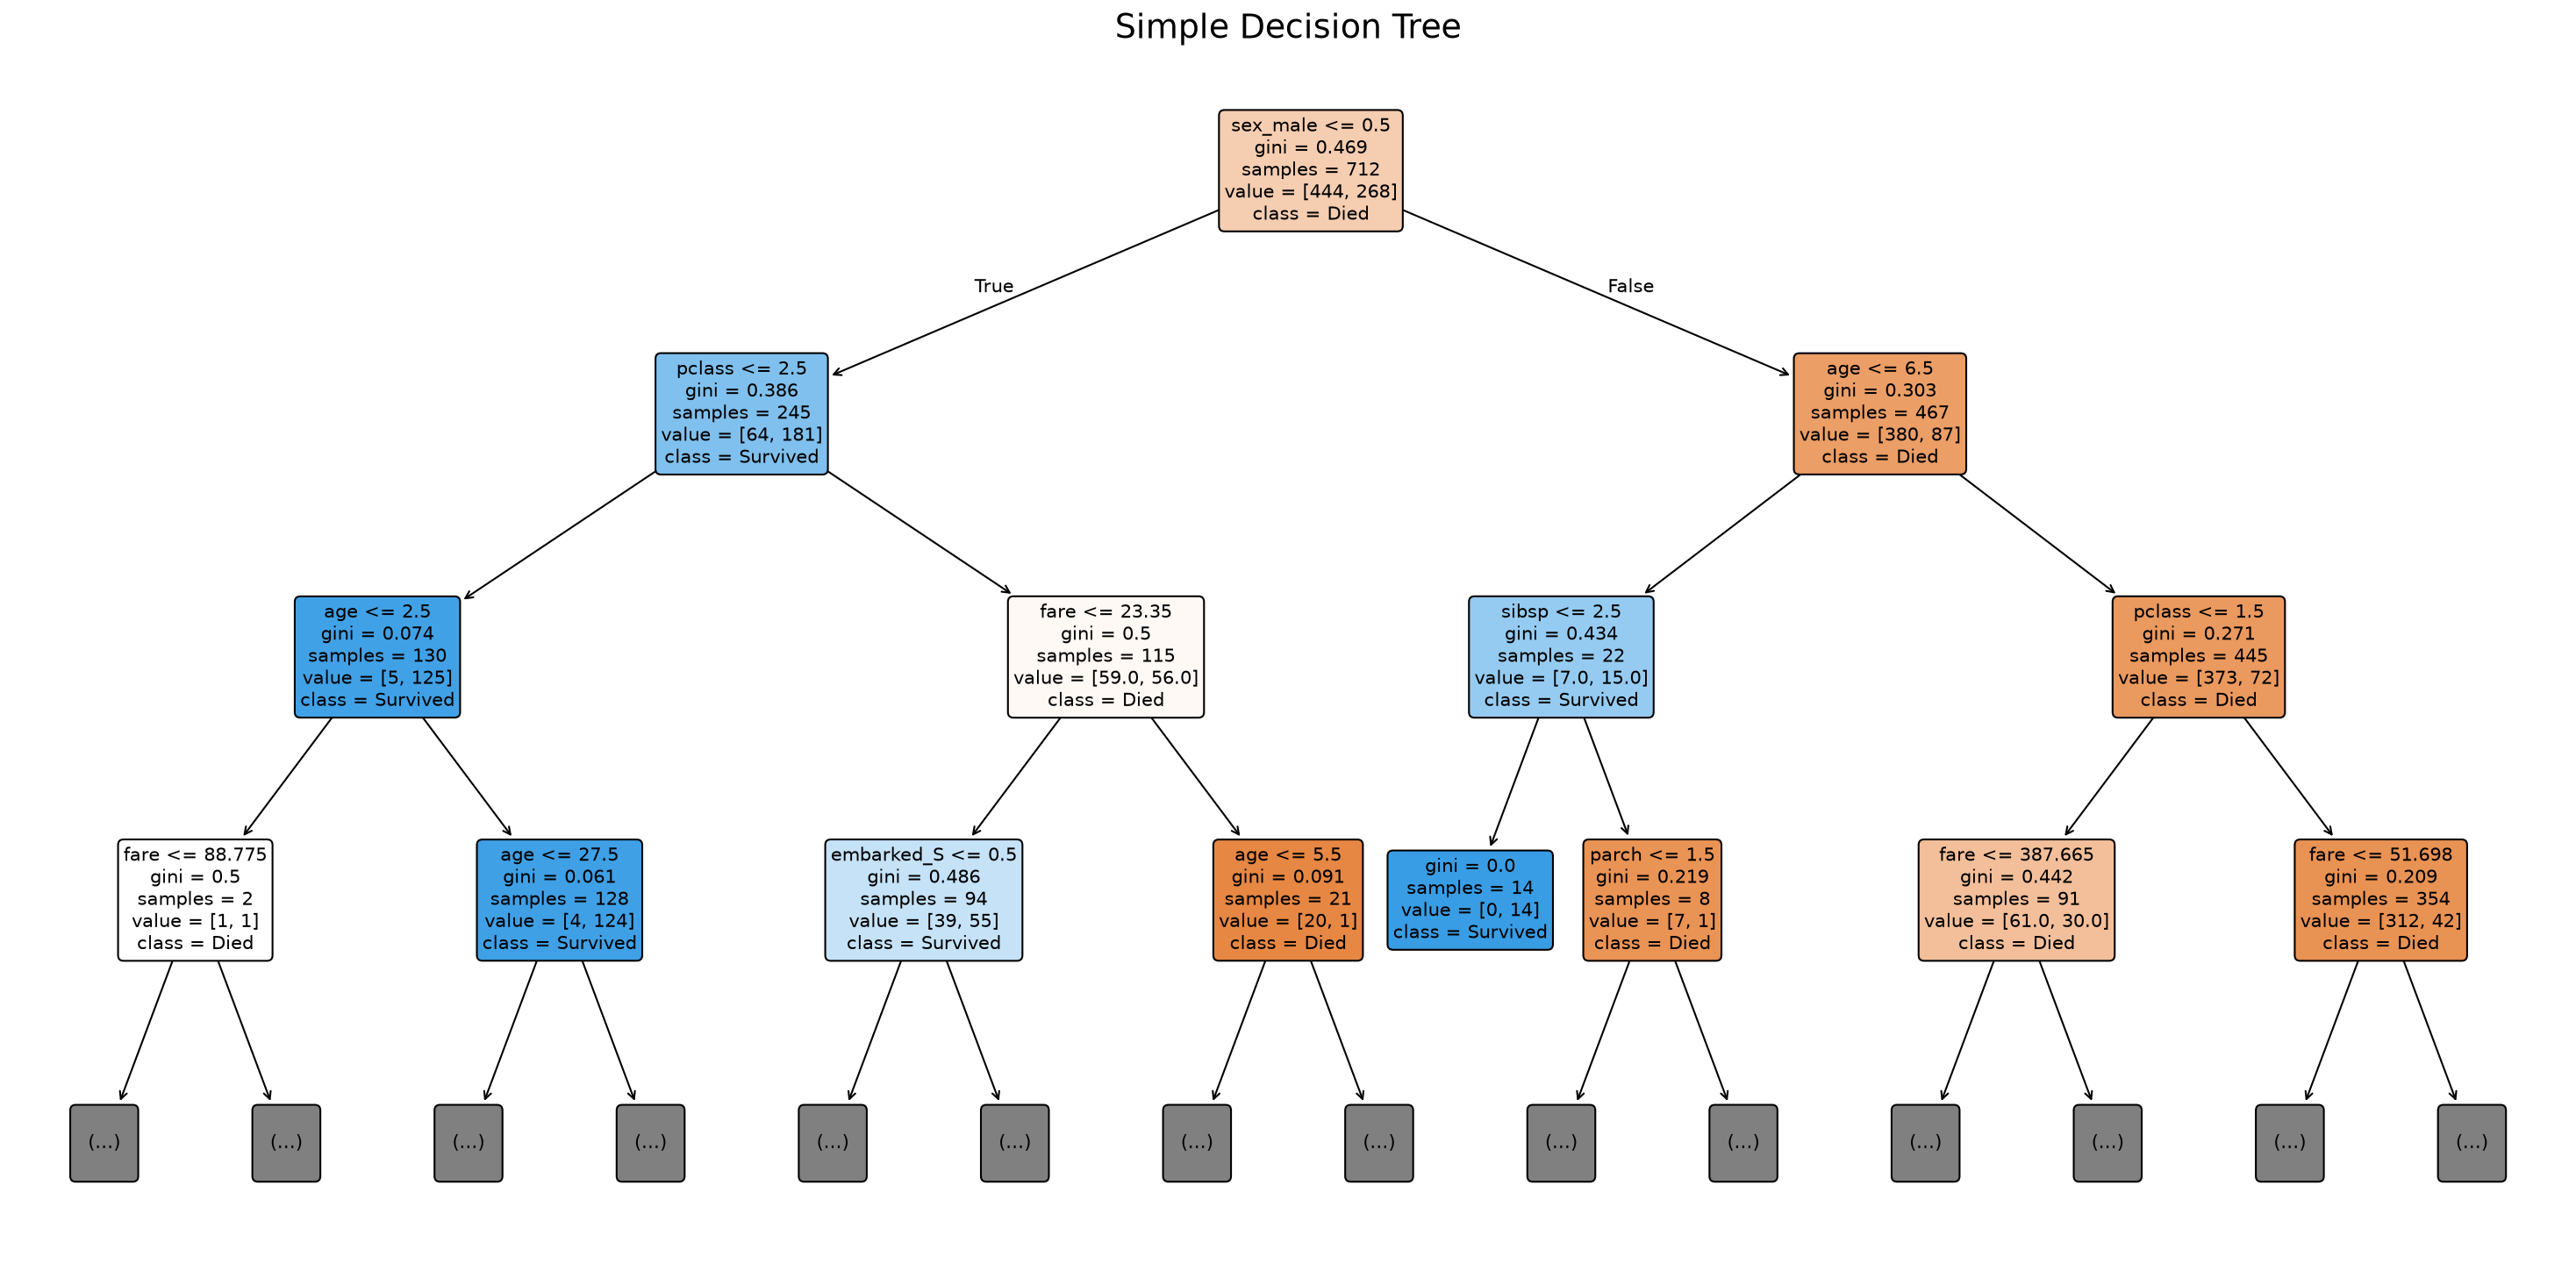

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12), dpi=150) 


plot_tree(tree_model, 
          feature_names=X.columns,    
          class_names=['Died', 'Survived'], 
          filled=True, 
          rounded=True, 
          max_depth=3,               
          fontsize=10)                

plt.title("Simple Decision Tree", fontsize=18)
plt.show()

## Pre_pruning testing

Depth:  1 | train acc: 0.7879 | test acc: 0.7821
Depth:  2 | train acc: 0.8034 | test acc: 0.7654
Depth:  3 | train acc: 0.8343 | test acc: 0.7989
Depth:  4 | train acc: 0.8399 | test acc: 0.7989
Depth:  5 | train acc: 0.8511 | test acc: 0.7989
Depth:  6 | train acc: 0.8666 | test acc: 0.8045
Depth:  7 | train acc: 0.8834 | test acc: 0.7989
Depth:  8 | train acc: 0.8989 | test acc: 0.7933
Depth:  9 | train acc: 0.9073 | test acc: 0.7989
Depth: 10 | train acc: 0.9129 | test acc: 0.7933
Depth: 11 | train acc: 0.9256 | test acc: 0.7989
Depth: 12 | train acc: 0.9340 | test acc: 0.7877
Depth: 13 | train acc: 0.9424 | test acc: 0.7877
Depth: 14 | train acc: 0.9522 | test acc: 0.7765
Depth: 15 | train acc: 0.9551 | test acc: 0.7765


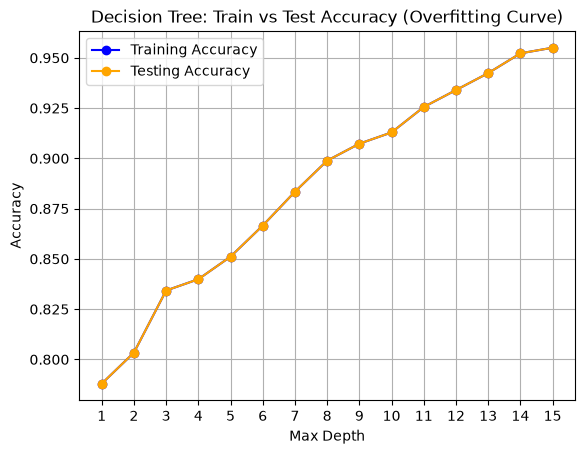

In [24]:
import matplotlib.pyplot as plt

train_scores = []
test_scores = []

depths = range(1,16)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train,y_train)

    train_accuracy = accuracy_score(y_train, tree.predict(X_train))
    test_accuracy = accuracy_score(y_test, tree.predict(X_test))

    train_scores.append(train_accuracy)
    test_scores.append(train_accuracy)

    print(f"Depth: {depth:2d} | train acc: {train_accuracy:.4f} | test acc: {test_accuracy:.4f}")


# plot 
plt.Figure(figsize=(10,5))
plt.plot(depths, train_scores, marker='o', label='Training Accuracy', color='blue')
plt.plot(depths, test_scores, marker='o', label='Testing Accuracy', color='orange')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Train vs Test Accuracy (Overfitting Curve)')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()


--- Pre-Pruning: Min Samples Leaf Testing ---
Min Leaf:  1 | Train Acc: 0.9789 | Test Acc: 0.7821
Min Leaf:  3 | Train Acc: 0.9017 | Test Acc: 0.8547
Min Leaf:  5 | Train Acc: 0.8750 | Test Acc: 0.8380
Min Leaf:  7 | Train Acc: 0.8680 | Test Acc: 0.8492
Min Leaf:  9 | Train Acc: 0.8596 | Test Acc: 0.8380
Min Leaf: 11 | Train Acc: 0.8441 | Test Acc: 0.8156
Min Leaf: 13 | Train Acc: 0.8385 | Test Acc: 0.7933
Min Leaf: 15 | Train Acc: 0.8385 | Test Acc: 0.7933
Min Leaf: 17 | Train Acc: 0.8357 | Test Acc: 0.7933
Min Leaf: 19 | Train Acc: 0.8357 | Test Acc: 0.7933
Min Leaf: 21 | Train Acc: 0.8357 | Test Acc: 0.7933
Min Leaf: 23 | Train Acc: 0.8329 | Test Acc: 0.7709
Min Leaf: 25 | Train Acc: 0.8244 | Test Acc: 0.7933
Min Leaf: 27 | Train Acc: 0.8202 | Test Acc: 0.7933
Min Leaf: 29 | Train Acc: 0.8244 | Test Acc: 0.8045
Min Leaf: 31 | Train Acc: 0.8216 | Test Acc: 0.7989


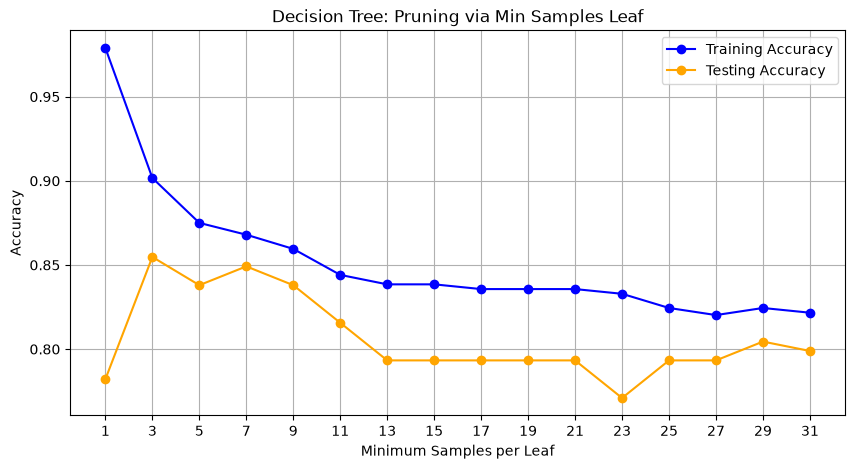

In [25]:
import matplotlib.pyplot as plt

leaf_train_scores = []
leaf_test_scores = []

leaf_values = range(1, 32, 2) 

print("--- Pre-Pruning: Min Samples Leaf Testing ---")
for min_leaf in leaf_values:
    
    tree = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    tree.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    
    leaf_train_scores.append(train_acc)
    leaf_test_scores.append(test_acc)
    
    print(f"Min Leaf: {min_leaf:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(leaf_values, leaf_train_scores, marker='o', label='Training Accuracy', color='blue')
plt.plot(leaf_values, leaf_test_scores, marker='o', label='Testing Accuracy', color='orange')
plt.xlabel('Minimum Samples per Leaf')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Pruning via Min Samples Leaf')
plt.xticks(leaf_values)
plt.legend()
plt.grid(True)
plt.show()

## Post-Pruning (Cost Complexity Pruning) 


--- Post-Pruning: CCP Alpha Testing ---
Optimal CCP Alpha : 0.00190
Best Test Accuracy: 0.8324 (Train: 0.8834)


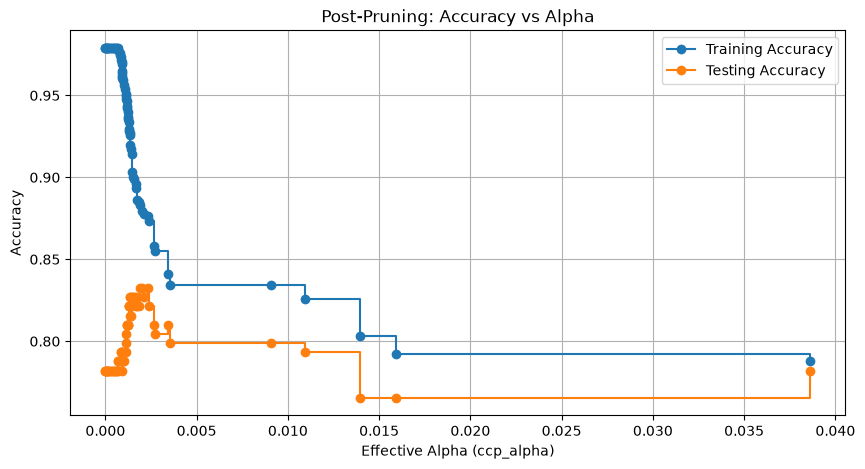

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Get the cost complexity pruning path to find optimal alpha values
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Remove the last maximum alpha value (it prunes the tree down to a single node)
ccp_alphas = ccp_alphas[:-1]

# Lists to store models and their scores
clfs = []
train_scores = []
test_scores = []

print("--- Post-Pruning: CCP Alpha Testing ---")

# 2. Train a Decision Tree for each alpha value
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    clfs.append(model)
    
    # Calculate and store accuracies
    t_acc = accuracy_score(y_train, model.predict(X_train))
    te_acc = accuracy_score(y_test, model.predict(X_test))
    
    train_scores.append(t_acc)
    test_scores.append(te_acc)

# 3. Find the best alpha that gives the highest test accuracy
best_index = test_scores.index(max(test_scores))
best_alpha = ccp_alphas[best_index]
best_test_acc = test_scores[best_index]
best_train_acc = train_scores[best_index]

print(f"Optimal CCP Alpha : {best_alpha:.5f}")
print(f"Best Test Accuracy: {best_test_acc:.4f} (Train: {best_train_acc:.4f})")

# 4. Plot Accuracy vs Alpha to visualize the pruning process
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Training Accuracy', drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='o', label='Testing Accuracy', drawstyle="steps-post")
plt.xlabel("Effective Alpha (ccp_alpha)")
plt.ylabel("Accuracy")
plt.title("Post-Pruning: Accuracy vs Alpha")
plt.legend()
plt.grid(True)
plt.show()

## Final Combined Pruned Model

--- Final Combined Pruned Model ---
Train Accuracy: 0.8441
Test Accuracy : 0.7989


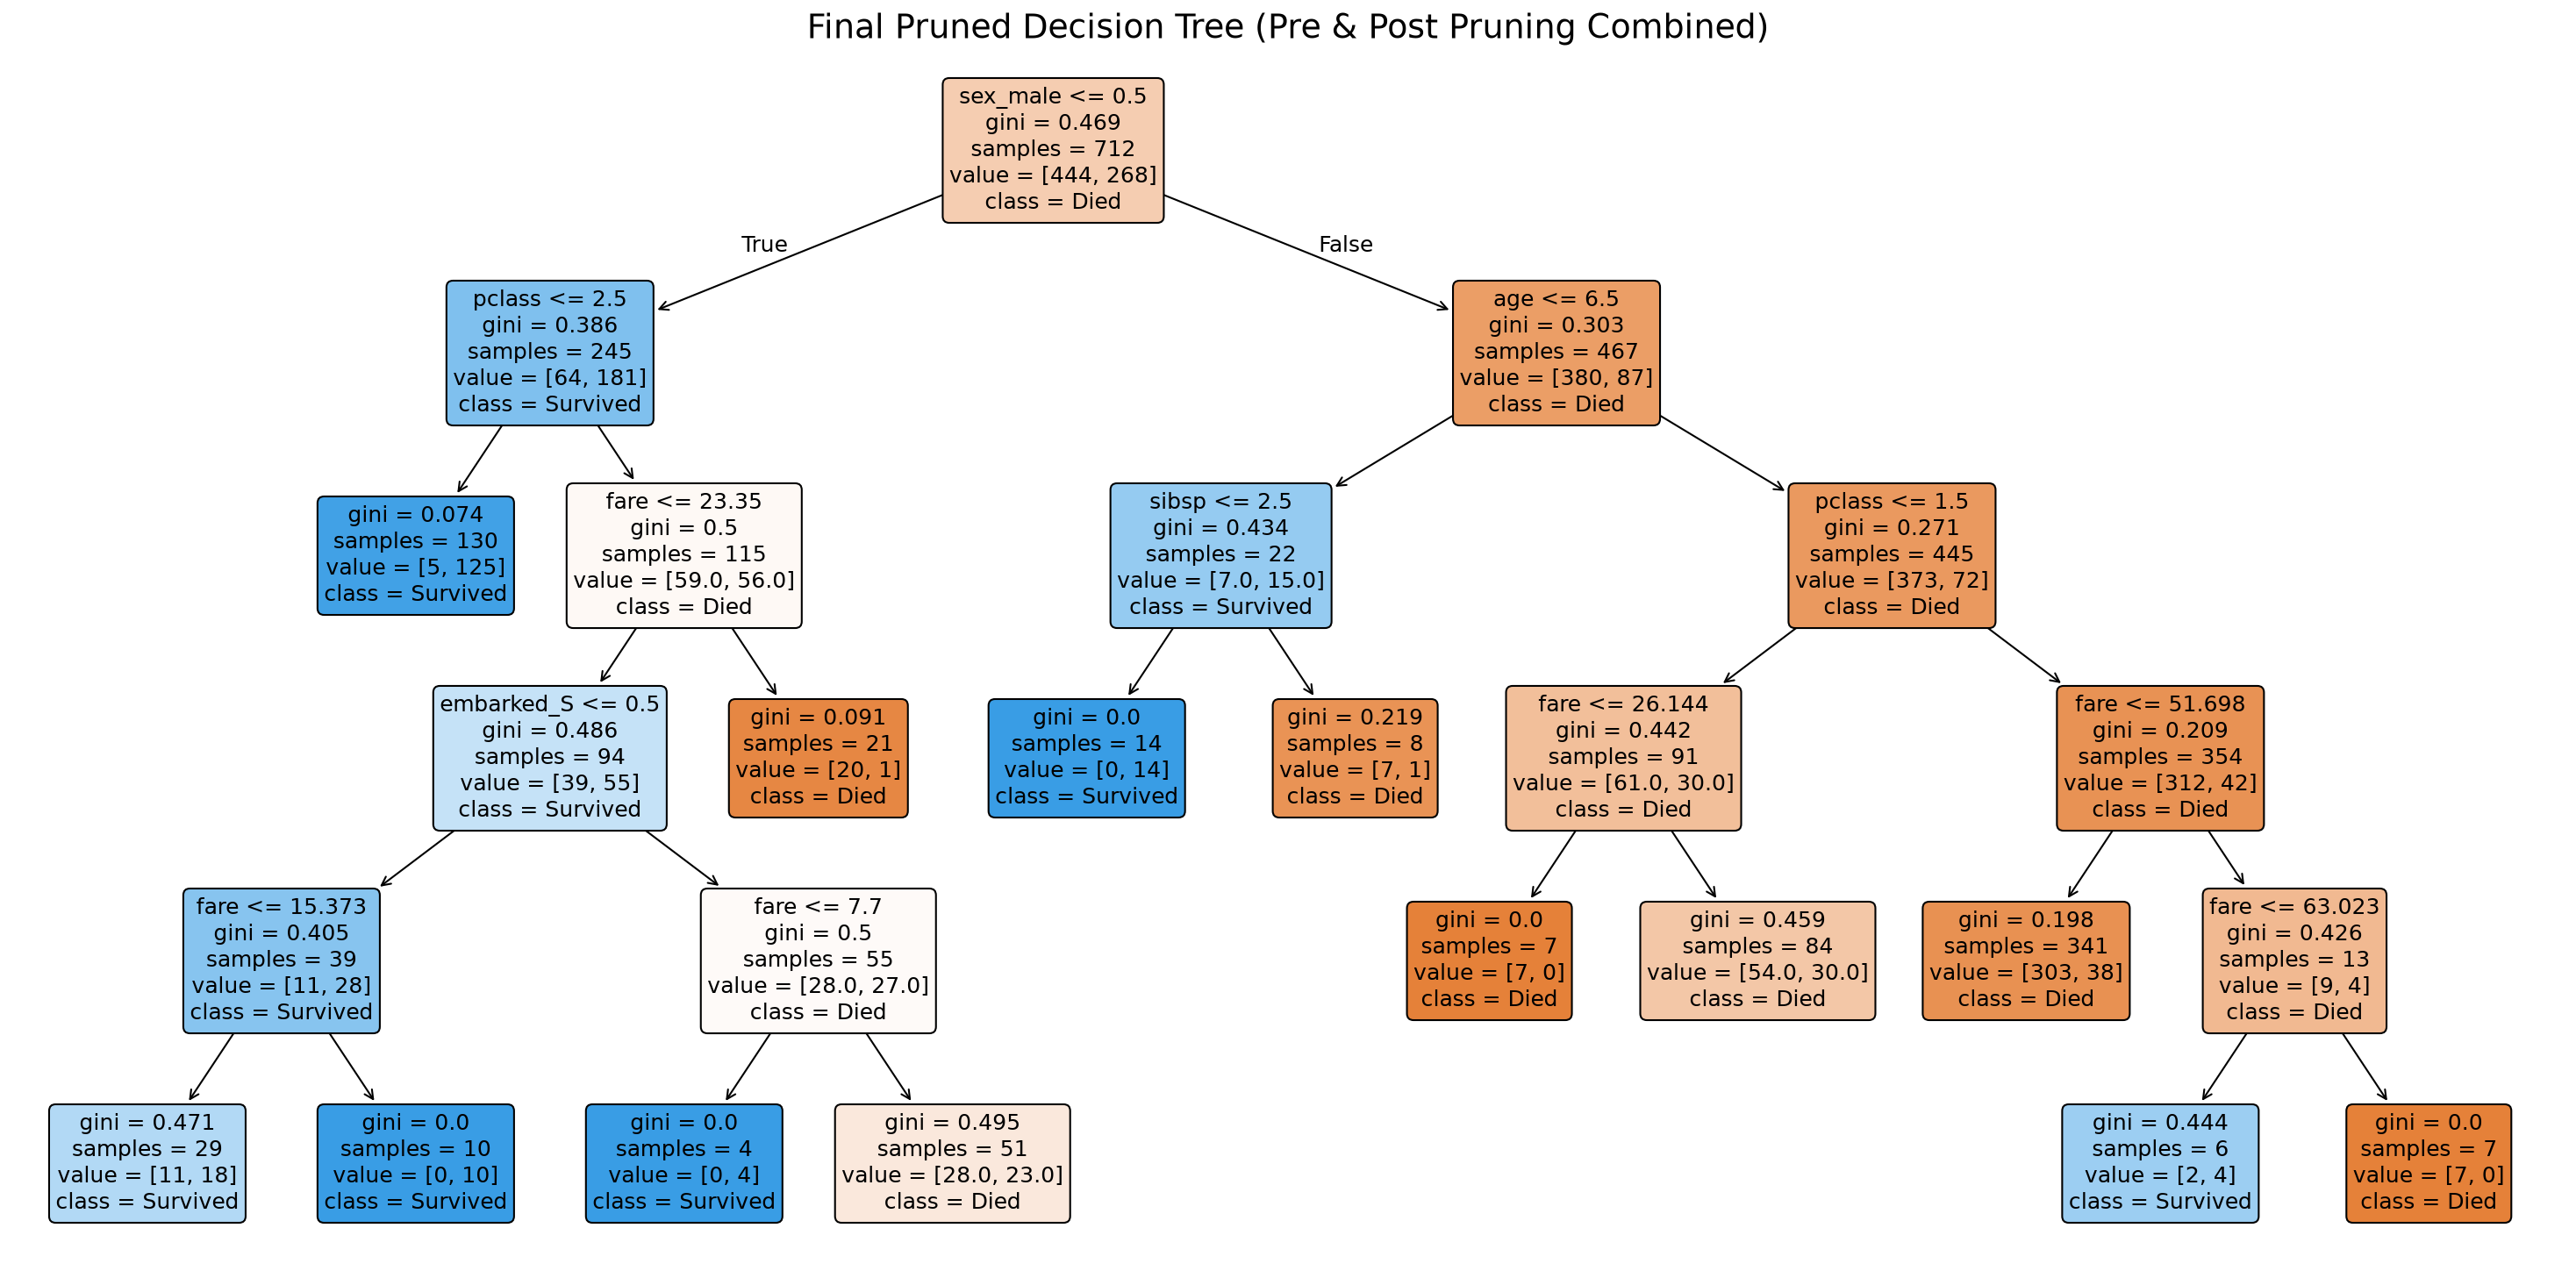

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

# 1. Initialize the model combining both Pre-pruning and Post-pruning optimal values
final_combined_tree = DecisionTreeClassifier(
    max_depth=5,              
    min_samples_leaf=3,       
    ccp_alpha=0.00190,       
    random_state=42
)

# 2. Train the final combined model
final_combined_tree.fit(X_train, y_train)

# 3. Calculate and display final accuracies
final_train_acc = accuracy_score(y_train, final_combined_tree.predict(X_train))
final_test_acc = accuracy_score(y_test, final_combined_tree.predict(X_test))

print("--- Final Combined Pruned Model ---")
print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Test Accuracy : {final_test_acc:.4f}")

# 4. Plot the final, clean, and highly optimized decision tree
plt.figure(figsize=(25, 12), dpi=150)
plot_tree(final_combined_tree, 
          feature_names=X.columns, 
          class_names=['Died', 'Survived'], 
          filled=True, 
          rounded=True, 
          fontsize=12)  # Slightly larger font since the tree is now pruned and compact

plt.title("Final Pruned Decision Tree (Pre & Post Pruning Combined)", fontsize=18)
plt.show()